# 02 - One-Dimensional Chignolin Acceleration CV

Train a single shared CV from structural dynamics only, then check whether that one scalar consistently correlates with Tm / MFPT-related metrics across epochs. No linear combination search is used.


In [13]:
# Requires: pip install -e .

import itertools
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

from lss.models.cv_tm_predictor import BackboneModel, LinearBackboneModel
from lss.peptide import load_target_table
from lss.peptide_tm import (
    build_metric_dataset,
    build_holdout_split,
    extract_cv_sequences,
    metric_stats_from_train_mutants,
    prediction_stats,
    release_cuda_memory,
    run_sim_epoch,
)
from lss.plotting import PAPER_COLORS, apply_editorial_style, paper_caption, style_axes
from lss.utils import resolve_device

apply_editorial_style()

try:
    display
except NameError:
    def display(*args, **kwargs):
        return None



In [14]:
# Config.

device = torch.device(resolve_device('cuda'))
force_train = True
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
print('device:', device)
print('seed:', seed)

backbone_type = 'linear'  # 'linear' or 'attention'
descriptor_token_dim = 32
base_run_name = f'chignolin_cv1_{backbone_type}_edge_stats_cv_to_dv_no_bias'
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
run_dir = ROOT / 'results' / base_run_name / 'run'
run_dir.mkdir(parents=True, exist_ok=True)

target_metric_names = ['Tm', 'log_mfpt', 'log_mfpt_ratio', 'hlda_evalue']

history = 1
frames_per_traj = 100000
take_every_kth_frame = 10
train_mutant_count = 12
hidden_size = 128
CVs = 8
token_sizes = (320, 80, 20, CVs)
heads = 1
transformer_layers = 2
pre_pyramid_layers = 2
dropout = 0.0
batch_size = 64
weight_decay = 1e-5
sim_learning_rate = 1e-4
sim_epochs = 40
sim_early_stop_patience = 6
cls_weight = 0.1
time_lag_steps = 0

cfg = {
    'seed': seed,
    'history': history,
    'frames_per_traj': frames_per_traj,
    'take_every_kth_frame': take_every_kth_frame,
    'train_mutant_count': train_mutant_count,
    'backbone_type': backbone_type,
    'hidden_size': hidden_size,
    'descriptor_token_dim': descriptor_token_dim,
    'linear_backbone_pooling': 'mean_std_max',
    'linear_backbone_descriptor_identity': True,
    'linear_backbone_token_mlp': 'linear_gelu_linear_gelu',
    'CVs': CVs,
    'token_sizes': token_sizes,
    'heads': heads,
    'transformer_layers': transformer_layers,
    'pre_pyramid_layers': pre_pyramid_layers,
    'dropout': dropout,
    'batch_size': batch_size,
    'weight_decay': weight_decay,
    'sim_learning_rate': sim_learning_rate,
    'sim_epochs': sim_epochs,
    'cls_weight': cls_weight,
    'time_lag_steps': time_lag_steps,
}
print(json.dumps({k: (list(v) if isinstance(v, tuple) else v) for k, v in cfg.items()}, indent=2))


device: cuda
seed: 1472693868
{
  "seed": 1472693868,
  "history": 1,
  "frames_per_traj": 100000,
  "take_every_kth_frame": 10,
  "train_mutant_count": 12,
  "backbone_type": "linear",
  "hidden_size": 128,
  "descriptor_token_dim": 32,
  "linear_backbone_pooling": "mean_std_max",
  "linear_backbone_descriptor_identity": true,
  "linear_backbone_token_mlp": "linear_gelu_linear_gelu",
  "CVs": 8,
  "token_sizes": [
    320,
    80,
    20,
    8
  ],
  "heads": 1,
  "transformer_layers": 2,
  "pre_pyramid_layers": 2,
  "dropout": 0.0,
  "batch_size": 64,
  "weight_decay": 1e-05,
  "sim_learning_rate": 0.0001,
  "sim_epochs": 40,
  "cls_weight": 0.1,
  "time_lag_steps": 0
}


In [15]:
# Data.

packed = torch.load(ROOT / 'data' / 'peptide' / 'hlda_trajectories_compact.pt', map_location='cpu', weights_only=False)
x_all = packed.get('x_all', packed.get('x')).float()
time_all = packed.get('time_all', packed.get('time')).long()
offsets = packed.get('offsets', packed.get('traj_offsets')).long()
labels = packed['labels'].long()
mutants = packed['mutants']
feature_names = [str(name) for name in packed['feature_names']]
uniq_mutants_all = sorted(set(str(m) for m in mutants))
n_feat = int(x_all.shape[1])
distance_descriptor_indices = [i for i, name in enumerate(feature_names) if name.startswith('d') and name[1:].isdigit()]
distance_descriptor_names = [feature_names[i] for i in distance_descriptor_indices]
distance_descriptor_pairs = [(int(name[1]), int(name[2])) for name in distance_descriptor_names]
max_residue_index = max(max(pair) for pair in distance_descriptor_pairs)
distance_descriptor_metadata = torch.tensor(
    [
        [
            i / max_residue_index,
            j / max_residue_index,
            abs(j - i) / max_residue_index,
        ]
        for i, j in distance_descriptor_pairs
    ],
    dtype=torch.float32,
)

target_df = load_target_table(
    ROOT / 'data' / 'peptide' / 'Tm.csv',
    ROOT / 'data' / 'peptide' / 'mfpt_slice_thr0p34_tF0p25_tU0p57.csv',
    ROOT / 'data' / 'peptide' / 'hlda_evalues_thr0p34_tF0p25_tU0p57.csv',
)
target_df['log_mfpt'] = np.log(target_df['mfpt'].astype(float))
uniq_mutants = [m for m in uniq_mutants_all if m in set(target_df['mutant'].astype(str))]

print('features:', n_feat)
print('distance descriptors used as edge-like CV tokens:', len(distance_descriptor_indices), distance_descriptor_names)
print('edge-like metadata columns: residue_i_norm, residue_j_norm, sequence_separation_norm')
print('usable mutants:', len(uniq_mutants))
display(target_df.head())


features: 29
distance descriptors used as edge-like CV tokens: 28 ['d03', 'd04', 'd05', 'd06', 'd07', 'd08', 'd09', 'd14', 'd15', 'd16', 'd17', 'd18', 'd19', 'd25', 'd26', 'd27', 'd28', 'd29', 'd36', 'd37', 'd38', 'd39', 'd47', 'd48', 'd49', 'd58', 'd59', 'd69']
edge-like metadata columns: residue_i_norm, residue_j_norm, sequence_separation_norm
usable mutants: 37


,mutant,Tm,mfpt,mfpt_ratio,log_mfpt_ratio,hlda_evalue,log_mfpt
0,WT,407.0,6.252921e+05,1.000000,0.000000,4919.890072,13.345974
1,D2N,420.0,3.952522e+05,0.632108,-0.458695,6592.658671,12.887279
2,D2A,394.0,8.198605e+05,1.311164,0.270915,6533.154022,13.616889
3,Y9E,290.0,4.443935e+04,0.071070,-2.644093,2720.063395,10.701881
4,T7Q,403.0,1.115225e+06,1.783526,0.578592,7664.947324,13.924566


In [16]:
# Helpers.

def build_backbone():
    if backbone_type == 'linear':
        return LinearBackboneModel(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            token_sizes=token_sizes,
            dropout=dropout,
            descriptor_token_dim=descriptor_token_dim,
            descriptor_indices=distance_descriptor_indices,
            descriptor_metadata=distance_descriptor_metadata,
        ).to(device)
    if backbone_type == 'attention':
        return BackboneModel(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            token_sizes=token_sizes,
            heads=heads,
            token_layers=transformer_layers,
            dropout=dropout,
            pre_pyramid_layers=pre_pyramid_layers,
            linear_cv_decoder=True,
        ).to(device)
    raise ValueError(f'Unknown backbone_type={backbone_type!r}')


def descriptor_residue_indices(feature_name):
    name = str(feature_name)
    if name.startswith('d') and name[1:].isdigit():
        return [int(ch) for ch in name[1:]]
    return []


def aggregate_residue_weights(feature_names, weights):
    rows = []
    for feature_name, weight in zip(feature_names, np.asarray(weights, dtype=float)):
        for residue_index in descriptor_residue_indices(feature_name):
            rows.append({'residue_index': residue_index, 'abs_weight': abs(float(weight))})
    return pd.DataFrame(rows).groupby('residue_index', as_index=False)['abs_weight'].sum().sort_values('abs_weight', ascending=False)


def _corr(x, y, method='pearson'):
    clean = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(clean) < 3 or clean['x'].std() < 1e-12 or clean['y'].std() < 1e-12:
        return np.nan
    return float(clean['x'].corr(clean['y'], method=method))


def summarize_cv_by_mutant(backbone, x_tensor, samples_df, split_name):
    cv_sequences = extract_cv_sequences(backbone, x_tensor, samples_df, batch_size=batch_size, device=device)
    rows = []
    sample_state = samples_df.reset_index(drop=True).copy()
    traj_label = {int(i): float(labels[i]) for i in range(len(labels))}
    sample_state['state_label'] = sample_state['traj_id'].map(traj_label).astype(float)
    frame_rows = []
    for mutant, seq in cv_sequences.items():
        sub = sample_state[sample_state['mutant'].astype(str).eq(str(mutant))].copy().reset_index(drop=True)
        cv = seq[:, 0].detach().cpu().numpy().astype(float)
        sub['cv'] = cv[:len(sub)]
        frame_rows.append(sub[['mutant', 'traj_id', 't', 'state_label', 'cv']].assign(split=split_name))
        folded = sub[sub['state_label'].lt(0.5)]['cv'].to_numpy(float)
        unfolded = sub[sub['state_label'].ge(0.5)]['cv'].to_numpy(float)
        row = {
            'split': split_name,
            'mutant': str(mutant),
            'cv_mean': float(np.mean(cv)),
            'cv_std': float(np.std(cv)),
            'cv_median': float(np.median(cv)),
            'cv_min': float(np.min(cv)),
            'cv_max': float(np.max(cv)),
            'cv_range': float(np.max(cv) - np.min(cv)),
        }
        if len(folded) >= 3 and len(unfolded) >= 3:
            row['cv_folded_mean'] = float(np.mean(folded))
            row['cv_unfolded_mean'] = float(np.mean(unfolded))
            row['cv_state_delta'] = float(np.mean(unfolded) - np.mean(folded))
            row['cv_fisher_J'] = float((np.mean(folded) - np.mean(unfolded)) ** 2 / (np.var(folded) + np.var(unfolded) + 1e-6))
        rows.append(row)
    summary = pd.DataFrame(rows).merge(target_df, on='mutant', how='left')
    frames = pd.concat(frame_rows, ignore_index=True) if frame_rows else pd.DataFrame()
    return summary, frames


def direct_cv_metric_rows(summary_df, epoch):
    feature_cols = ['cv_mean', 'cv_median', 'cv_std', 'cv_range', 'cv_state_delta', 'cv_fisher_J']
    rows = []
    for split_name, split_df in summary_df.groupby('split', sort=False):
        for metric in target_metric_names:
            for feature in feature_cols:
                if feature not in split_df:
                    continue
                pearson = _corr(split_df[feature], split_df[metric], method='pearson')
                spearman = _corr(split_df[feature], split_df[metric], method='spearman')
                rows.append({
                    'epoch': int(epoch),
                    'split': split_name,
                    'metric': metric,
                    'feature': feature,
                    'pearson': pearson,
                    'spearman': spearman,
                    'r2': pearson ** 2 if np.isfinite(pearson) else np.nan,
                })
    return pd.DataFrame(rows)


In [17]:
# Split and train one no-bias one-dimensional CV backbone.
# Training uses only the structural acceleration/dV objective and basin classifier from 02.
# Metrics are used only for external correlation of the learned scalar CV.

split_payload = build_holdout_split(
    run_seed=seed,
    uniq_mutants=uniq_mutants,
    train_mutant_count=train_mutant_count,
    mutants=mutants,
    history=history,
    time_lag_steps=time_lag_steps,
    frames_per_traj=frames_per_traj,
    take_every_kth_frame=take_every_kth_frame,
    x_all=x_all,
    time_all=time_all,
    offsets=offsets,
    labels=labels,
    n_feat=n_feat,
)

backbone_ckpt = run_dir / 'backbone_best_structural.pt'
sim_history_csv = run_dir / 'sim_history.csv'
cv_metric_csv = run_dir / 'cv1_metric_correlation_by_epoch.csv'
cv_summary_csv = run_dir / 'cv1_mutant_summary_final.csv'
cv_frames_csv = run_dir / 'cv1_frame_values_final.csv'
config_json = run_dir / 'config.json'
config_json.write_text(json.dumps({k: (list(v) if isinstance(v, tuple) else v) for k, v in cfg.items()}, indent=2))

release_cuda_memory()
backbone = build_backbone()
opt = torch.optim.AdamW(backbone.parameters(), lr=sim_learning_rate, weight_decay=weight_decay)
train_loader = DataLoader(TensorDataset(split_payload['train_x'], split_payload['train_dv'], split_payload['train_cls']), batch_size=batch_size, shuffle=True, drop_last=False)
holdout_loader = DataLoader(TensorDataset(split_payload['holdout_x'], split_payload['holdout_dv'], split_payload['holdout_cls']), batch_size=batch_size, shuffle=False, drop_last=False)

history_rows = []
metric_corr_parts = []
best_holdout_loss = float('inf')
best_state = None
bad_epochs = 0

for epoch in range(1, sim_epochs + 1):
    train_info = run_sim_epoch(backbone, train_loader, device=device, cls_weight=cls_weight, opt=opt)
    holdout_info = run_sim_epoch(backbone, holdout_loader, device=device, cls_weight=cls_weight, opt=None)
    train_summary, _ = summarize_cv_by_mutant(backbone, split_payload['train_x'], split_payload['train_samples_df'], 'train')
    holdout_summary, _ = summarize_cv_by_mutant(backbone, split_payload['holdout_x'], split_payload['holdout_samples_df'], 'holdout')
    epoch_summary = pd.concat([train_summary, holdout_summary], ignore_index=True)
    epoch_corr = direct_cv_metric_rows(epoch_summary, epoch)
    metric_corr_parts.append(epoch_corr)

    row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_info.items()}, **{f'holdout_{k}': v for k, v in holdout_info.items()}}
    for _, corr_row in epoch_corr.iterrows():
        key = f"{corr_row['split']}_{corr_row['metric']}_{corr_row['feature']}_pearson"
        row[key] = corr_row['pearson']
    history_rows.append(row)

    def _lookup(split_name, metric, feature):
        sub = epoch_corr[epoch_corr['split'].eq(split_name) & epoch_corr['metric'].eq(metric) & epoch_corr['feature'].eq(feature)]
        return float(sub['pearson'].iloc[0]) if not sub.empty else float('nan')

    print(
        f"epoch {epoch:03d} train={train_info['sim_loss']:.5f} holdout={holdout_info['sim_loss']:.5f} | "
        f"heldout Tm: mean r={_lookup('holdout', 'Tm', 'cv_mean'):.2f}, delta r={_lookup('holdout', 'Tm', 'cv_state_delta'):.2f}, J r={_lookup('holdout', 'Tm', 'cv_fisher_J'):.2f} | "
        f"heldout log_mfpt: mean r={_lookup('holdout', 'log_mfpt', 'cv_mean'):.2f}, delta r={_lookup('holdout', 'log_mfpt', 'cv_state_delta'):.2f}, J r={_lookup('holdout', 'log_mfpt', 'cv_fisher_J'):.2f}"
    )

    if holdout_info['sim_loss'] < best_holdout_loss - 1e-5:
        best_holdout_loss = holdout_info['sim_loss']
        best_state = {k: v.detach().cpu().clone() for k, v in backbone.state_dict().items()}
        torch.save({'seed': seed, 'epoch': epoch, 'model_state_dict': best_state, 'holdout_sim_loss': best_holdout_loss}, backbone_ckpt)
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= sim_early_stop_patience:
            break

sim_history_df = pd.DataFrame(history_rows)
cv_metric_corr_df = pd.concat(metric_corr_parts, ignore_index=True)
sim_history_df.to_csv(sim_history_csv, index=False)
cv_metric_corr_df.to_csv(cv_metric_csv, index=False)

if best_state is not None:
    backbone.load_state_dict(best_state)
backbone.eval()
final_train_summary, final_train_frames = summarize_cv_by_mutant(backbone, split_payload['train_x'], split_payload['train_samples_df'], 'train')
final_holdout_summary, final_holdout_frames = summarize_cv_by_mutant(backbone, split_payload['holdout_x'], split_payload['holdout_samples_df'], 'holdout')
final_cv_summary_df = pd.concat([final_train_summary, final_holdout_summary], ignore_index=True)
final_cv_frames_df = pd.concat([final_train_frames, final_holdout_frames], ignore_index=True)
final_cv_summary_df.to_csv(cv_summary_csv, index=False)
final_cv_frames_df.to_csv(cv_frames_csv, index=False)
print('saved:', run_dir)


epoch 001 train=0.98546 holdout=0.95508 | heldout Tm: mean r=-0.45, delta r=0.05, J r=0.00 | heldout log_mfpt: mean r=-0.27, delta r=0.01, J r=0.05
epoch 002 train=0.93309 holdout=0.93468 | heldout Tm: mean r=-0.57, delta r=0.12, J r=-0.12 | heldout log_mfpt: mean r=-0.27, delta r=0.09, J r=-0.05
epoch 003 train=0.91941 holdout=0.93366 | heldout Tm: mean r=-0.59, delta r=0.05, J r=-0.08 | heldout log_mfpt: mean r=-0.24, delta r=0.07, J r=-0.00
epoch 004 train=0.91199 holdout=0.92534 | heldout Tm: mean r=-0.57, delta r=0.19, J r=-0.15 | heldout log_mfpt: mean r=-0.27, delta r=0.10, J r=-0.04
epoch 005 train=0.90654 holdout=0.91978 | heldout Tm: mean r=-0.57, delta r=0.14, J r=-0.11 | heldout log_mfpt: mean r=-0.27, delta r=0.09, J r=-0.02
epoch 006 train=0.90212 holdout=0.91498 | heldout Tm: mean r=-0.58, delta r=0.23, J r=-0.16 | heldout log_mfpt: mean r=-0.29, delta r=0.13, J r=-0.08
epoch 007 train=0.89835 holdout=0.91487 | heldout Tm: mean r=-0.59, delta r=0.23, J r=-0.14 | heldout 

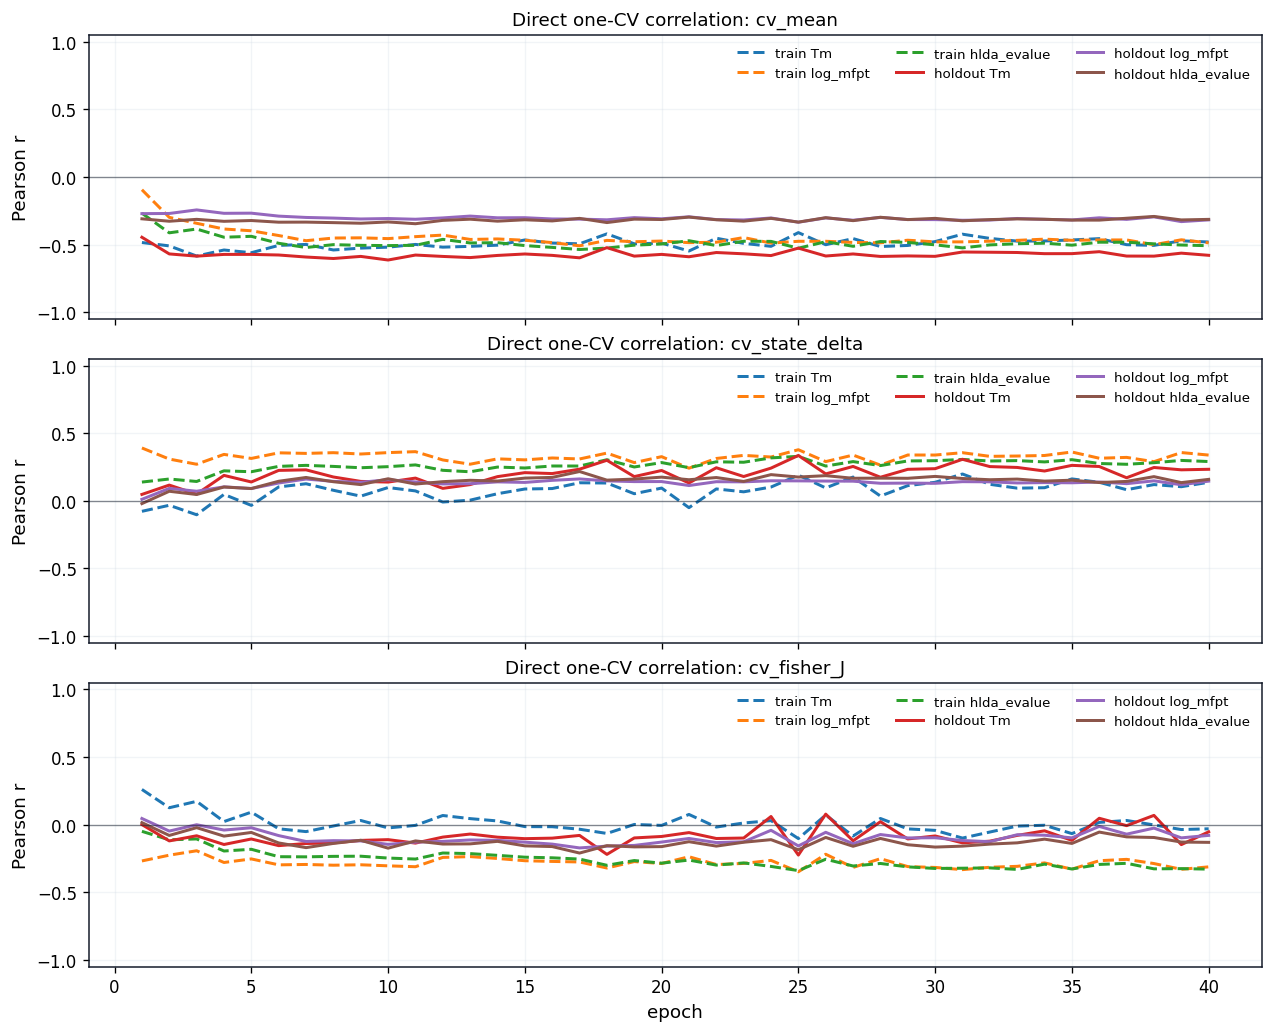

,metric,feature,epoch,pearson,spearman,r2
457,Tm,cv_median,10,-0.6141,-0.6832,0.3771
456,Tm,cv_mean,10,-0.6139,-0.6644,0.3768
1180,Tm,cv_state_delta,25,0.3356,0.4134,0.1127
122,Tm,cv_std,3,-0.3229,-0.3091,0.1043
75,Tm,cv_range,2,-0.3134,-0.2610,0.0982
1181,Tm,cv_fisher_J,25,-0.2247,-0.4034,0.0505
522,hlda_evalue,cv_mean,11,-0.3455,-0.2931,0.1194
379,hlda_evalue,cv_median,8,-0.3271,-0.3177,0.1070
476,hlda_evalue,cv_std,10,-0.2186,-0.1685,0.0478
814,hlda_evalue,cv_state_delta,17,0.2168,0.2062,0.0470


In [18]:
# Plot direct CV-to-metric correlations across epochs.

plot_df = cv_metric_corr_df[cv_metric_corr_df['metric'].isin(['Tm', 'log_mfpt', 'hlda_evalue'])].copy()
plot_features = ['cv_mean', 'cv_state_delta', 'cv_fisher_J']
fig, axes = plt.subplots(len(plot_features), 1, figsize=(10.5, 8.5), sharex=True, constrained_layout=True)
if len(plot_features) == 1:
    axes = [axes]
for ax, feature in zip(axes, plot_features):
    sub = plot_df[plot_df['feature'].eq(feature)]
    for (split_name, metric), group in sub.groupby(['split', 'metric'], sort=False):
        group = group.sort_values('epoch')
        ls = '-' if split_name == 'holdout' else '--'
        ax.plot(group['epoch'], group['pearson'], lw=1.8, ls=ls, label=f'{split_name} {metric}')
    ax.axhline(0, color=PAPER_COLORS['ink'], lw=0.8, alpha=0.5)
    ax.set_title(f'Direct one-CV correlation: {feature}')
    ax.set_ylabel('Pearson r')
    ax.set_ylim(-1.05, 1.05)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, ncol=3)
axes[-1].set_xlabel('epoch')
plt.show()

best_abs = (
    cv_metric_corr_df[cv_metric_corr_df['split'].eq('holdout')]
    .assign(abs_pearson=lambda df: df['pearson'].abs())
    .sort_values(['metric', 'abs_pearson'], ascending=[True, False])
    .groupby(['metric', 'feature'], as_index=False)
    .head(1)
    .sort_values(['metric', 'abs_pearson'], ascending=[True, False])
)
display(best_abs[['metric', 'feature', 'epoch', 'pearson', 'spearman', 'r2']].round(4))


# Final heldout scatter for the single learned CV summaries.

scatter_features = ['cv_mean', 'cv_state_delta', 'cv_fisher_J']
scatter_metrics = ['Tm', 'log_mfpt', 'hlda_evalue']
heldout_final = final_cv_summary_df[final_cv_summary_df['split'].eq('holdout')].copy()
fig, axes = plt.subplots(len(scatter_features), len(scatter_metrics), figsize=(12, 9), constrained_layout=True)
for i, feature in enumerate(scatter_features):
    for j, metric in enumerate(scatter_metrics):
        ax = axes[i, j]
        clean = heldout_final[[feature, metric, 'mutant']].dropna()
        ax.scatter(clean[feature], clean[metric], s=36, alpha=0.85, color=PAPER_COLORS['blue'])
        for _, row in clean.iterrows():
            ax.text(row[feature], row[metric], row['mutant'], fontsize=6, alpha=0.65)
        r = clean[feature].corr(clean[metric]) if len(clean) >= 3 else np.nan
        ax.set_title(f'{feature} vs {metric} | r={r:.2f}')
        ax.set_xlabel(feature)
        ax.set_ylabel(metric)
        ax.grid(alpha=0.25)
plt.show()


One-dimensional simulator decoder weights: dV = W * CV


,feature,cv_1_weight,abs_weight
27,d59,0.57852,0.57852
28,d69,0.55706,0.55706
8,d14,0.47571,0.47571
25,d49,0.46643,0.46643
9,d15,0.39629,0.39629
14,d25,0.35944,0.35944
20,d37,-0.32756,0.32756
26,d58,0.28770,0.28770
16,d27,-0.26207,0.26207
19,d36,-0.26141,0.26141


,residue_index,abs_weight
9,9,2.10143
5,5,1.85592
4,4,1.37118
1,1,1.30945
6,6,1.01575
3,3,0.96520
2,2,0.95595
7,7,0.90646
8,8,0.89666
0,0,0.84633


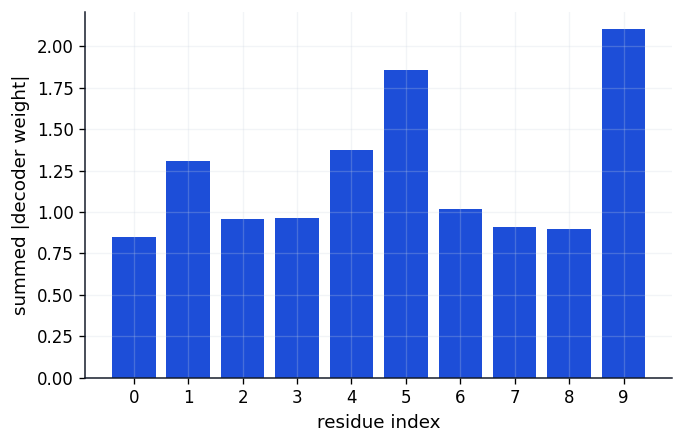

In [19]:
# Decoder weights for the one-dimensional CV: dV = W * CV, no bias.

W = backbone.dv_head.weight.detach().cpu().numpy()
weight_df = pd.DataFrame({'feature': feature_names, 'cv_1_weight': W[:, 0], 'abs_weight': np.abs(W[:, 0])}).sort_values('abs_weight', ascending=False)
residue_weight_df = aggregate_residue_weights(feature_names, W[:, 0])

paper_caption('One-dimensional simulator decoder weights: dV = W * CV')
display(weight_df.head(15).round(5))
display(residue_weight_df.round(5))

fig, ax = plt.subplots(1, 1, figsize=(5.8, 3.8))
residue_plot = residue_weight_df.sort_values('residue_index')
ax.bar(residue_plot['residue_index'].astype(str), residue_plot['abs_weight'], color=PAPER_COLORS['blue'])
style_axes(ax, xlabel='residue index', ylabel='summed |decoder weight|')
plt.tight_layout()
plt.show()


## Notes

- This notebook now trains exactly one CV (`CVs = 1`).
- Training loss is still structural: acceleration/dV reconstruction plus the folded/unfolded classifier from 02.
- `Tm`, `log_mfpt`, `log_mfpt_ratio`, and `hlda_evalue` are not used in training.
- There is no linear-combination search. The analysis only checks direct correlations of scalar summaries of the one CV.
- The most important summaries are `cv_mean`, `cv_state_delta` (unfolded mean minus folded mean), and `cv_fisher_J`.
- The correlation-over-epoch plot is the main diagnostic: a useful CV should keep the same sign and similar magnitude on train and holdout across many epochs, not spike at one epoch only.
